In [120]:
# ============================================================
# GITHUB MACHINE LEARNING REPOSITORY ANALYSIS
# LEVEL 3 - SECOND TERM PROJECT
# ============================================================

In [121]:
# Import Libraries
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [122]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All libraries imported successfully!")

All libraries imported successfully!


# GitHub Machine Learning Repository Analysis

## Project Overview

This project analyzes Machine Learning repositories collected from the
GitHub API.

The project includes:

- Data collection using the GitHub API
- Data cleaning and preparation using Pandas
- Data storage using SQLite
- Data analysis using SQL
- Data visualization using Matplotlib
- Interpretation of results
- Responsible use of public data

# Task 1 – Build the Data Collection Pipeline

In this task, repository data is collected from the GitHub API and transformed
into a clean and structured dataset.

In [123]:
# ============================================================
# STEP 1 - COLLECT DATA FROM GITHUB API
# ============================================================

In [124]:
url = (
    "https://api.github.com/search/repositories"
    "?q=machine+learning"
    "&sort=stars"
    "&order=desc"
    "&per_page=100"
)

In [125]:
# Send request to GitHub API
response = requests.get(url)

In [126]:
# Check if request was successful
response.raise_for_status()

In [127]:
# Convert response to JSON
data = response.json()

In [128]:
print("GitHub API data collected successfully!")
print("Number of repositories returned:", len(data["items"]))

GitHub API data collected successfully!
Number of repositories returned: 100


In [129]:
# ============================================================
# STEP 2 - CREATE THE DATASET
# ============================================================

In [130]:
# Extract repositories from JSON
repositories = data["items"]

In [131]:
# Convert JSON data to DataFrame
df = pd.DataFrame(repositories)

print("DataFrame created successfully!")

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset columns:")
print(df.columns.tolist())

DataFrame created successfully!

Dataset shape:
(100, 82)

First 5 rows:


,id,node_id,name,full_name,private,owner,html_url,description,fork,url,forks_url,keys_url,collaborators_url,teams_url,hooks_url,issue_events_url,events_url,assignees_url,branches_url,tags_url,blobs_url,git_tags_url,git_refs_url,trees_url,statuses_url,languages_url,stargazers_url,contributors_url,subscribers_url,subscription_url,commits_url,git_commits_url,comments_url,issue_comment_url,contents_url,compare_url,merges_url,archive_url,downloads_url,issues_url,pulls_url,milestones_url,notifications_url,labels_url,releases_url,deployments_url,created_at,updated_at,pushed_at,git_url,ssh_url,clone_url,svn_url,homepage,size,stargazers_count,watchers_count,language,has_issues,has_projects,has_downloads,has_wiki,has_pages,has_discussions,forks_count,mirror_url,archived,disabled,open_issues_count,license,allow_forking,is_template,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,2015-11-07T01:19:20Z,2026-08-24T13:29:22Z,2026-08-24T13:27:59Z,git://github.com/tensorflow/tensorflow.git,git@github.com:tensorflow/tensorflow.git,https://github.com/tensorflow/tensorflow.git,https://github.com/tensorflow/tensorflow,https://tensorflow.org,1369295,197382,197382,C++,True,True,False,False,False,False,76114,None,False,False,2935,"{'key': 'apache-2.0', 'name': 'Apache License ...",True,False,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76114,2935,197382,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,https://api.github.com/repos/huggingface/trans...,https://api.github.com/repos/huggingface/trans...,https://api.github.com/repos/huggingface/tra


Dataset columns:
['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url', 'description', 'fork', 'url', 'forks_url', 'keys_url', 'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url', 'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url', 'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url', 'languages_url', 'stargazers_url', 'contributors_url', 'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url', 'comments_url', 'issue_comment_url', 'contents_url', 'compare_url', 'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url', 'milestones_url', 'notifications_url', 'labels_url', 'releases_url', 'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url', 'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size', 'stargazers_count', 'watchers_count', 'language', 'has_issues', 'has_projects', 'has_downloads', 'has_wiki', 'has_pages', 'has_discussions', 'forks_count', 'mirror_url', 'archived', 'disabled'

In [132]:
# ============================================================
# STEP 3 - SELECT REQUIRED COLUMNS
# ============================================================

In [133]:
required_columns = [
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]

df = df[required_columns].copy()

print("Required columns selected successfully!")

display(df.head())

Required columns selected successfully!


,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197382,76114,197382,2935,2015-11-07T01:19:20Z,2026-08-24T13:29:22Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164395,34337,164395,2413,2018-10-29T13:56:00Z,2026-08-24T13:23:36Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89740,22056,89740,13,2021-03-03T01:34:05Z,2026-08-24T13:13:56Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82638,15278,82638,53,2018-08-21T11:20:39Z,2026-08-24T11:37:22Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74141,15620,74141,26,2014-07-15T19:11:19Z,2026-08-24T13:23:53Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [134]:
# ============================================================
# STEP 4 - EXTRACT REQUIRED VALUES
# ============================================================

In [135]:
# Extract GitHub owner username
df["owner"] = df["owner"].apply(
    lambda x: x.get("login") if isinstance(x, dict) else None
)

In [136]:
# Extract license name
df["license"] = df["license"].apply(
    lambda x: x.get("name") if isinstance(x, dict) else None
)

print("Nested owner and license values extracted successfully!")

display(df.head())

Nested owner and license values extracted successfully!


,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197382,76114,197382,2935,2015-11-07T01:19:20Z,2026-08-24T13:29:22Z,Apache License 2.0
1,transformers,huggingface,Python,164395,34337,164395,2413,2018-10-29T13:56:00Z,2026-08-24T13:23:36Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89740,22056,89740,13,2021-03-03T01:34:05Z,2026-08-24T13:13:56Z,MIT License
3,funNLP,fighting41love,Python,82638,15278,82638,53,2018-08-21T11:20:39Z,2026-08-24T11:37:22Z,None
4,awesome-machine-learning,josephmisiti,Python,74141,15620,74141,26,2014-07-15T19:11:19Z,2026-08-24T13:23:53Z,Other


In [137]:
# ============================================================
# STEP 5 - HANDLE MISSING VALUES
# ============================================================

In [138]:
print("Missing values BEFORE cleaning:")
display(df.isnull().sum())

Missing values BEFORE cleaning:


,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [139]:
# Replace missing values with suitable values
df["owner"] = df["owner"].fillna("Unknown")
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("No License")

print("\nMissing values AFTER cleaning:")
display(df.isnull().sum())


Missing values AFTER cleaning:


,0
name,0
owner,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,0


In [140]:
# ============================================================
# STEP 6 - HANDLE DUPLICATE RECORDS
# ============================================================

In [141]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [142]:
# Remove duplicates
df = df.drop_duplicates().copy()

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(100, 10)


In [143]:
# ============================================================
# STEP 7 - PREPARE THE DATASET
# ============================================================

In [144]:
# Convert date columns
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [145]:
# Rename columns
df.rename(
    columns={
        "stargazers_count": "stars",
        "forks_count": "forks",
        "watchers_count": "watchers",
        "open_issues_count": "open_issues",
        "created_at": "created_date",
        "updated_at": "updated_date"
    },
    inplace=True
)

print("Dataset prepared successfully!")

print("\nFinal columns:")
print(df.columns.tolist())

display(df.head())

Dataset prepared successfully!

Final columns:
['name', 'owner', 'language', 'stars', 'forks', 'watchers', 'open_issues', 'created_date', 'updated_date', 'license']


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197382,76114,197382,2935,2015-11-07 01:19:20+00:00,2026-08-24 13:29:22+00:00,Apache License 2.0
1,transformers,huggingface,Python,164395,34337,164395,2413,2018-10-29 13:56:00+00:00,2026-08-24 13:23:36+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89740,22056,89740,13,2021-03-03 01:34:05+00:00,2026-08-24 13:13:56+00:00,MIT License
3,funNLP,fighting41love,Python,82638,15278,82638,53,2018-08-21 11:20:39+00:00,2026-08-24 11:37:22+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74141,15620,74141,26,2014-07-15 19:11:19+00:00,2026-08-24 13:23:53+00:00,Other


In [146]:
# ============================================================
# STEP 8 - SAVE AND VERIFY THE DATASET
# ============================================================

In [147]:
csv_file = "github_projects.csv"

In [148]:
# Save dataset
df.to_csv(
    csv_file,
    index=False
)

print(f"Dataset saved successfully as: {csv_file}")

Dataset saved successfully as: github_projects.csv


In [149]:
# Reload CSV
df_check = pd.read_csv(csv_file)

print("\nReloaded dataset:")
display(df_check.head())

print("\nReloaded dataset shape:")
print(df_check.shape)

print("\nTask 1 completed successfully!")


Reloaded dataset:


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197382,76114,197382,2935,2015-11-07 01:19:20+00:00,2026-08-24 13:29:22+00:00,Apache License 2.0
1,transformers,huggingface,Python,164395,34337,164395,2413,2018-10-29 13:56:00+00:00,2026-08-24 13:23:36+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89740,22056,89740,13,2021-03-03 01:34:05+00:00,2026-08-24 13:13:56+00:00,MIT License
3,funNLP,fighting41love,Python,82638,15278,82638,53,2018-08-21 11:20:39+00:00,2026-08-24 11:37:22+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74141,15620,74141,26,2014-07-15 19:11:19+00:00,2026-08-24 13:23:53+00:00,Other



Reloaded dataset shape:
(100, 10)

Task 1 completed successfully!


## Task 1 – Data Preparation Summary

The GitHub API was used to collect Machine Learning repository data.

The raw JSON data was converted into a Pandas DataFrame. The required
columns were selected, and nested owner and license information was extracted.

Missing values were handled by replacing missing owner and language values
with "Unknown" and missing license values with "No License".

Duplicate records were checked and removed.

The date columns were converted into an appropriate date format, and the
required columns were renamed for easier analysis.

Finally, the cleaned dataset was saved as github_projects.csv and reloaded
to verify that it was stored correctly.

# Task 2 – Store and Analyze the Data

The cleaned dataset is stored in a SQLite database named
github_projects.db.

SQL queries are used to filter, search, sort, aggregate, and group
the repository data.

In [150]:
# ============================================================
# STEP 1 - CREATE SQLITE DATABASE
# ============================================================

In [151]:
database_file = "github_projects.db"

In [152]:
# Create SQLite connection
connection = sqlite3.connect(database_file)

In [153]:
# Store DataFrame in SQLite
df.to_sql(
    "Repositories",
    connection,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully!")
print("Table 'Repositories' created successfully.")

SQLite database created successfully!
Table 'Repositories' created successfully.


In [154]:
# ============================================================
# STEP 2 - FILTERING
# REPOSITORIES WITH MORE THAN 10,000 STARS
# ============================================================

In [155]:
query_stars = """
SELECT *
FROM Repositories
WHERE stars > 10000;
"""

result_stars = pd.read_sql_query(
    query_stars,
    connection
)

print("Repositories with more than 10,000 stars:")
display(result_stars)

Repositories with more than 10,000 stars:


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197382,76114,197382,2935,2015-11-07 01:19:20+00:00,2026-08-24 13:29:22+00:00,Apache License 2.0
1,transformers,huggingface,Python,164395,34337,164395,2413,2018-10-29 13:56:00+00:00,2026-08-24 13:23:36+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89740,22056,89740,13,2021-03-03 01:34:05+00:00,2026-08-24 13:13:56+00:00,MIT License
3,funNLP,fighting41love,Python,82638,15278,82638,53,2018-08-21 11:20:39+00:00,2026-08-24 11:37:22+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74141,15620,74141,26,2014-07-15 19:11:19+00:00,2026-08-24 13:23:53+00:00,Other
5,scikit-learn,scikit-learn,Python,67047,27308,67047,2128,2010-08-17 09:43:38+00:00,2026-08-24 13:28:36+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,gradio-app,Python,43412,3579,43412,170,2018-12-19 08:24:04+00:00,2026-08-24 11:30:54+00:00,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36483,7460,36483,68,2021-01-02 12:08:37+00:00,2026-08-24 13:17:48+00:00,No License
8,C-Plus-Plus,TheAlgorithms,C++,34599,7854,34599,28,2016-07-16 10:19:45+00:00,2026-08-24 12:02:18+00:00,MIT License
9,netron,lutzroeder,JavaScript,33395,3176,33395,18,2010-12-26 12:53:43+00:00,2026-08-24 13:25:58+00:00,MIT License


In [156]:
# ============================================================
# SEARCH FOR "MACHINE" IN REPOSITORY NAME
# ============================================================

In [157]:
query_machine = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
"""

result_machine = pd.read_sql_query(
    query_machine,
    connection
)

print("Repositories containing 'Machine' in their name:")
display(result_machine)

Repositories containing 'Machine' in their name:


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,awesome-machine-learning,josephmisiti,Python,74141,15620,74141,26,2014-07-15 19:11:19+00:00,2026-08-24 13:23:53+00:00,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36483,7460,36483,68,2021-01-02 12:08:37+00:00,2026-08-24 13:17:48+00:00,No License
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28866,6147,28866,32,2016-10-09 21:20:25+00:00,2026-08-24 11:58:16+00:00,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20864,2590,20864,31,2018-08-15 14:28:41+00:00,2026-08-24 09:28:38+00:00,MIT License
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20602,5551,20602,8,2018-05-09 12:33:08+00:00,2026-08-24 13:20:40+00:00,MIT License
6,stanford-cs-229-machine-learning,afshinea,Unknown,20151,4252,20151,20,2018-08-04 23:01:00+00:00,2026-08-24 13:17:19+00:00,MIT License
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18142,3969,18142,47,2015-09-12 14:51:38+00:00,2026-08-24 09:29:09+00:00,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,14005,3106,14005,3,2020-04-17 04:29:23+00:00,2026-08-24 11:32:42+00:00,No License
9,machine-learning-interview,khangich,Unknown,12791,2046,12791,9,2020-08-11 06:26:32+00:00,2026-08-24 10:30:12+00:00,No License


In [158]:
# ============================================================
# STEP 3 - LOGICAL OPERATORS
# ============================================================

In [159]:
# AND

query_and = """
SELECT name, owner, language, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 1000;
"""

result_and = pd.read_sql_query(
    query_and,
    connection
)

print("AND Query:")
display(result_and)

AND Query:


,name,owner,language,stars,forks
0,tensorflow,tensorflow,C++,197382,76114
1,transformers,huggingface,Python,164395,34337
2,ML-For-Beginners,microsoft,Jupyter Notebook,89740,22056
3,funNLP,fighting41love,Python,82638,15278
4,awesome-machine-learning,josephmisiti,Python,74141,15620
5,scikit-learn,scikit-learn,Python,67047,27308
6,gradio,gradio-app,Python,43412,3579
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36483,7460
8,C-Plus-Plus,TheAlgorithms,C++,34599,7854
9,netron,lutzroeder,JavaScript,33395,3176


In [160]:
# OR

query_or = """
SELECT name, owner, language, stars, forks
FROM Repositories
WHERE language = 'Python'
OR language = 'Jupyter Notebook';
"""

result_or = pd.read_sql_query(
    query_or,
    connection
)

print("OR Query:")
display(result_or)

OR Query:


,name,owner,language,stars,forks
0,transformers,huggingface,Python,164395,34337
1,ML-For-Beginners,microsoft,Jupyter Notebook,89740,22056
2,funNLP,fighting41love,Python,82638,15278
3,awesome-machine-learning,josephmisiti,Python,74141,15620
4,scikit-learn,scikit-learn,Python,67047,27308
5,gradio,gradio-app,Python,43412,3579
6,ML-From-Scratch,eriklindernoren,Python,32516,5431
7,linkedin-skill-assessments-quizzes,Ebazhanov,Python,28806,12905
8,cs249r_book,harvard-edge,Python,27994,3534
9,shap,shap,Jupyter Notebook,25699,3746


In [161]:
# NOT

query_not = """
SELECT name, owner, language, stars
FROM Repositories
WHERE NOT language = 'Unknown';
"""

result_not = pd.read_sql_query(
    query_not,
    connection
)

print("NOT Query:")
display(result_not)

NOT Query:


,name,owner,language,stars
0,tensorflow,tensorflow,C++,197382
1,transformers,huggingface,Python,164395
2,ML-For-Beginners,microsoft,Jupyter Notebook,89740
3,funNLP,fighting41love,Python,82638
4,awesome-machine-learning,josephmisiti,Python,74141
5,scikit-learn,scikit-learn,Python,67047
6,gradio,gradio-app,Python,43412
7,C-Plus-Plus,TheAlgorithms,C++,34599
8,netron,lutzroeder,JavaScript,33395
9,ML-From-Scratch,eriklindernoren,Python,32516


In [162]:
# ============================================================
# STEP 4 - SORTING AND LIMITING
# TOP 10 REPOSITORIES
# ============================================================

In [163]:
query_top10 = """
SELECT name, owner, language, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top10 = pd.read_sql_query(
    query_top10,
    connection
)

print("Top 10 repositories by number of stars:")
display(top10)

Top 10 repositories by number of stars:


,name,owner,language,stars,forks
0,tensorflow,tensorflow,C++,197382,76114
1,transformers,huggingface,Python,164395,34337
2,ML-For-Beginners,microsoft,Jupyter Notebook,89740,22056
3,funNLP,fighting41love,Python,82638,15278
4,awesome-machine-learning,josephmisiti,Python,74141,15620
5,scikit-learn,scikit-learn,Python,67047,27308
6,gradio,gradio-app,Python,43412,3579
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36483,7460
8,C-Plus-Plus,TheAlgorithms,C++,34599,7854
9,netron,lutzroeder,JavaScript,33395,3176


In [164]:
# ============================================================
# STEP 5 - AGGREGATE FUNCTIONS
# ============================================================

In [165]:
# COUNT

query_count = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""

count_result = pd.read_sql_query(
    query_count,
    connection
)

total_repositories = int(
    count_result.loc[0, "total_repositories"]
)

In [166]:
# AVERAGE

query_average = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""

average_result = pd.read_sql_query(
    query_average,
    connection
)

average_stars = float(
    average_result.loc[0, "average_stars"]
)


print("Total number of repositories:", total_repositories)
print("Average number of stars:", round(average_stars, 2))

Total number of repositories: 100
Average number of stars: 20828.0


In [167]:
# ============================================================
# STEP 6 - GROUPING ANALYSIS
# LANGUAGES WITH MORE THAN 5 REPOSITORIES
# ============================================================

In [168]:
query_languages = """
SELECT
    language,
    COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""

language_groups = pd.read_sql_query(
    query_languages,
    connection
)

print("Programming languages with more than 5 repositories:")

display(language_groups)

Programming languages with more than 5 repositories:


,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


## SQL Analysis Insights

The SQL analysis was used to identify highly popular repositories and
repositories whose names contain the word "Machine".

The AND, OR, and NOT logical operators were used to create more specific
conditions when querying the dataset.

The Top 10 query ranks repositories by their number of stars and identifies
the most popular repositories in the collected dataset.

COUNT and AVG were used to calculate the total number of repositories and
the average number of stars.

The GROUP BY and HAVING clauses were used to identify programming languages
that appear in more than five repositories.

In [169]:
# ============================================================
# STEP 7 - VISUALIZATION
# TOP 10 MOST POPULAR REPOSITORIES
# ============================================================

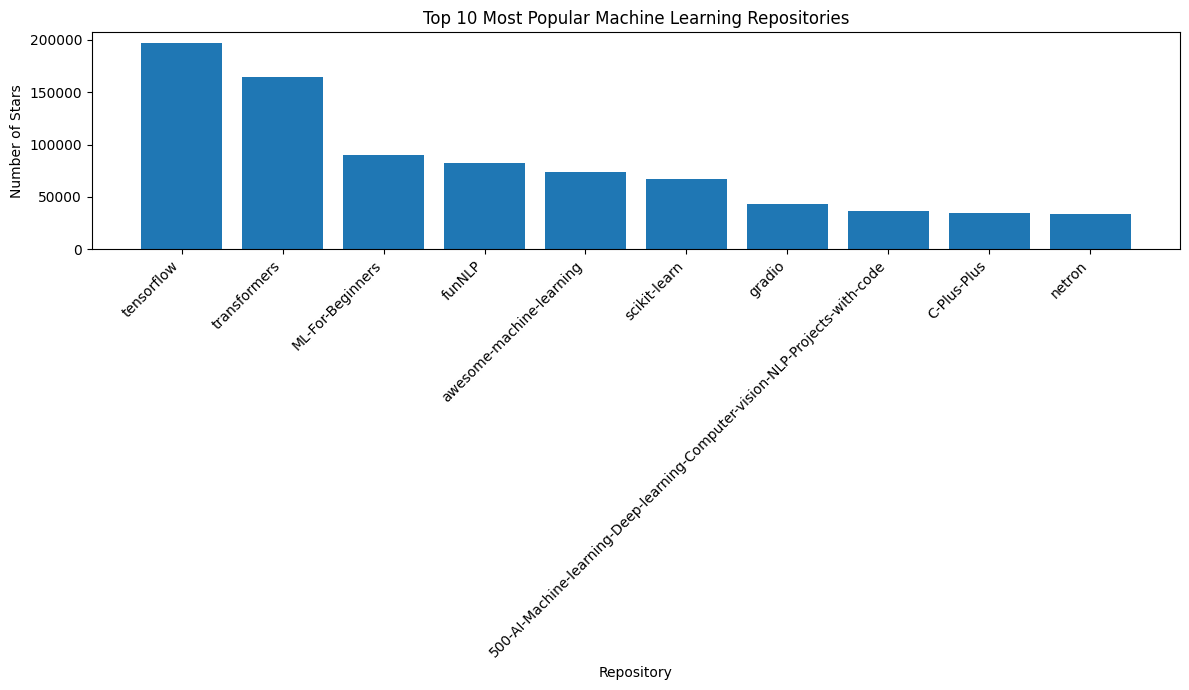

In [170]:
plt.figure(figsize=(12, 7))

plt.bar(
    top10["name"],
    top10["stars"]
)

plt.title(
    "Top 10 Most Popular Machine Learning Repositories"
)

plt.xlabel("Repository")

plt.ylabel("Number of Stars")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [171]:
# ============================================================
# VISUALIZATION
# REPOSITORY CREATION TRENDS
# ============================================================

In [172]:
# Convert created_date to datetime
df["created_date"] = pd.to_datetime(
    df["created_date"]
)

In [173]:
# Extract year
df["year"] = df["created_date"].dt.year

In [174]:
# Count repositories by year
creation_trend = (
    df.groupby("year")
    .size()
    .reset_index(name="repository_count")
)

print("Repository creation trend:")
display(creation_trend)

Repository creation trend:


,year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


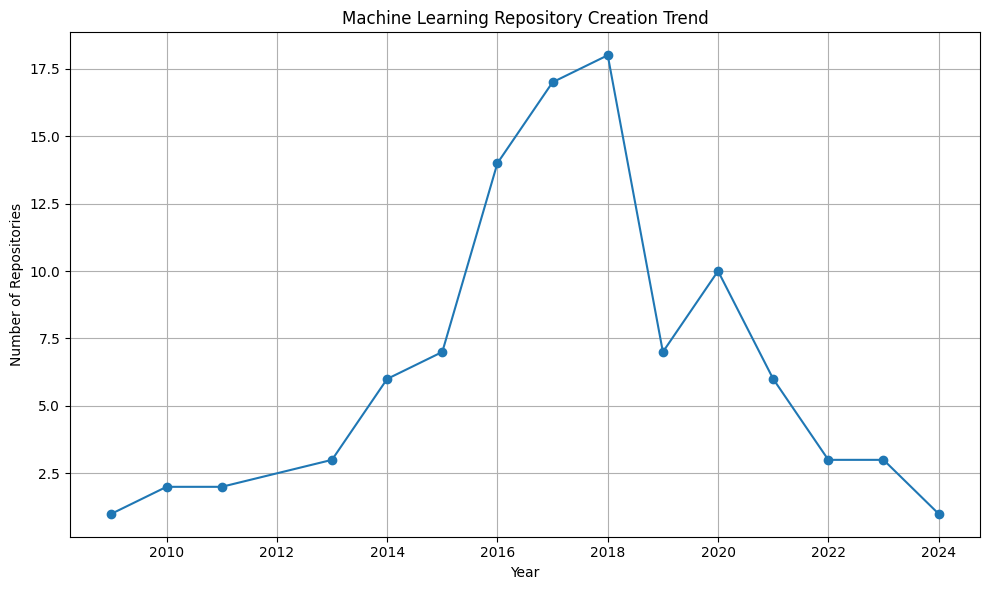

In [175]:
# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(
    creation_trend["year"],
    creation_trend["repository_count"],
    marker="o"
)

plt.title(
    "Machine Learning Repository Creation Trend"
)

plt.xlabel("Year")

plt.ylabel("Number of Repositories")

plt.grid(True)

plt.tight_layout()

plt.show()

## Visualization Insights

### Top 10 Repositories

The first visualization compares the Top 10 Machine Learning repositories
according to their number of GitHub stars. It provides a clear view of the
most popular repositories in the collected dataset.

### Repository Creation Trend

The second visualization shows how the number of repositories in the dataset
varies according to their creation year. This helps identify years with
relatively higher or lower repository creation activity.

In [176]:
# ============================================================
# STEP 8 - FINAL ANALYSIS SUMMARY
# ============================================================

In [177]:
print("=" * 70)
print("FINAL ANALYSIS SUMMARY")
print("=" * 70)

print("\nTotal repositories:")
print(total_repositories)

print("\nAverage number of stars:")
print(round(average_stars, 2))

print("\nTop 10 repositories:")
display(
    top10[
        [
            "name",
            "owner",
            "language",
            "stars",
            "forks"
        ]
    ]
)

print("\nProgramming languages with more than 5 repositories:")
display(language_groups)

FINAL ANALYSIS SUMMARY

Total repositories:
100

Average number of stars:
20828.0

Top 10 repositories:


,name,owner,language,stars,forks
0,tensorflow,tensorflow,C++,197382,76114
1,transformers,huggingface,Python,164395,34337
2,ML-For-Beginners,microsoft,Jupyter Notebook,89740,22056
3,funNLP,fighting41love,Python,82638,15278
4,awesome-machine-learning,josephmisiti,Python,74141,15620
5,scikit-learn,scikit-learn,Python,67047,27308
6,gradio,gradio-app,Python,43412,3579
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36483,7460
8,C-Plus-Plus,TheAlgorithms,C++,34599,7854
9,netron,lutzroeder,JavaScript,33395,3176



Programming languages with more than 5 repositories:


,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


# Final Insights

## Key Findings

- The Top 10 analysis identifies the repositories with the highest number
  of GitHub stars in the collected dataset.

- The programming language analysis shows which languages occur most
  frequently among the collected Machine Learning repositories.

- The repository creation trend shows how repository creation varies
  across different years.

- SQL filtering, searching, logical operators, sorting, aggregation,
  and grouping provide different ways to investigate the repository data.

- Data cleaning was an important step because the raw API data contained
  nested information and potentially missing or duplicated values.

## Business Conclusion

The analysis provides a structured overview of Machine Learning repositories
on GitHub. The results can help a software company understand repository
popularity, programming language usage, and repository creation activity.

These findings can support further investigation into Machine Learning
projects and trends on GitHub.

# Ethics Reflection

## 1. Why is it important to verify data collected from public APIs?

It is important to verify data collected from public APIs because public data
may contain missing, outdated, duplicated, or inaccurate information.
Verifying the data helps ensure that the analysis is based on reliable
information and reduces the possibility of incorrect results.

## 2. Why should data analysts document the source of their data?

Data analysts should document the source of their data so that others can
understand where the data came from, verify the information, and reproduce
the analysis. Documentation also improves transparency and makes the analysis
more trustworthy.

## 3. How can missing or inaccurate data affect data analysis and
decision-making?

Missing or inaccurate data can lead to incorrect calculations, misleading
patterns, and unreliable conclusions. If decisions are based on poor-quality
data, the resulting business decisions may also be incorrect. Therefore,
data should be checked and cleaned before analysis.

In [178]:
# ============================================================
# PROJECT COMPLETION
# ============================================================

In [179]:
# Close database connection
connection.close()

print("=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 70)

print("\nFiles created:")
print("- github_projects.csv")
print("- github_projects.db")

PROJECT COMPLETED SUCCESSFULLY!

Files created:
- github_projects.csv
- github_projects.db
